# ch197 — Randomized Linear Algebra

> **Prerequisites:** ch173 (SVD), ch174 (PCA), ch192 (Rank), ch194 (Condition Numbers)
> **You will learn:**
> - The Johnson-Lindenstrauss lemma and random projections
> - Randomized SVD: fast low-rank approximation with provable error bounds
> - Sketch-and-solve for large least-squares problems
> - When randomized algorithms are preferable to deterministic ones
> - Error bounds and the role of oversampling
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Full SVD of an $m \times n$ matrix costs $O(\min(m,n) \cdot mn)$ — infeasible for $m, n > 10^5$. **Randomized algorithms** exploit approximate low-rank structure: a random projection onto a small subspace captures most of the information, then we solve exactly in that reduced space.

These are not heuristics — they have provable error bounds. The **Johnson-Lindenstrauss (JL) lemma** guarantees that a random projection to $k = O(\log n / \epsilon^2)$ dimensions approximately preserves all $\binom{n}{2}$ pairwise distances simultaneously.

Common misconception: randomized methods are Monte Carlo algorithms that give different answers each run. In practice, a single random draw is taken; subsequent computation is exact. The randomness is in the construction of the projection, not the solution.

## 2. Intuition & Mental Models

**Random projection:** imagine $n$ points in $\mathbb{R}^d$. Project onto a random $k$-dimensional subspace. Since the subspace is random, it is unlikely to be aligned with any particular structured direction — so distances are approximately preserved. The JL lemma makes this precise.

**Randomized SVD:** (1) multiply $A$ by a random matrix $\Omega$ to sketch the column space, (2) find an orthonormal basis $Q$ for the sketch, (3) project $A$ onto $Q$ and compute the SVD of the small $Q^\top A$. This replaces $O(mn^2)$ with $O(mnk)$ where $k \ll \min(m,n)$.

**Think of it as:** casting a random fishing net in the high-dimensional space and catching the most important directions — then rigorously computing in the smaller space spanned by the catch.

## 3. Visualization

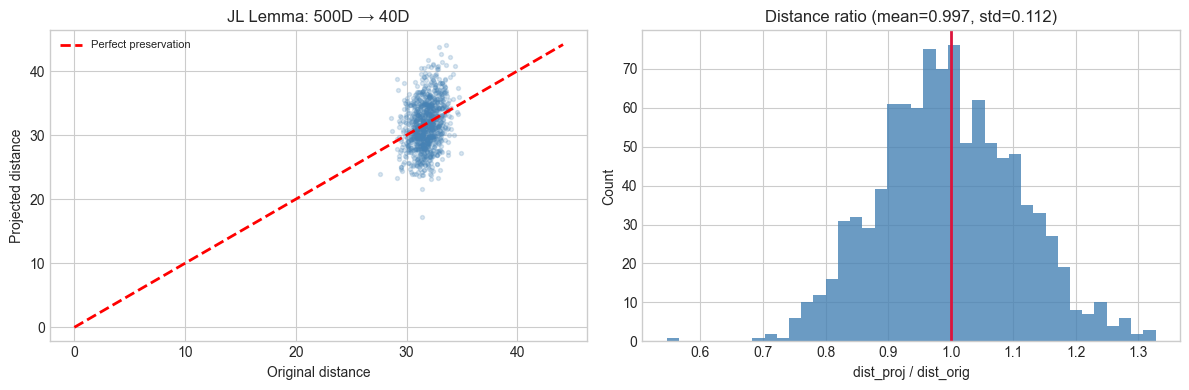

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

# JL Lemma demo: random projection preserves pairwise distances
N_PTS, D_ORIG, K_PROJ = 300, 500, 40
X = rng.normal(0, 1, (N_PTS, D_ORIG))
Omega = rng.normal(0, 1/np.sqrt(K_PROJ), (D_ORIG, K_PROJ))
X_proj = X @ Omega

# Sample pairwise distances
N_PAIRS = 1000
i_idx = rng.integers(0, N_PTS, N_PAIRS)
j_idx = rng.integers(0, N_PTS, N_PAIRS)
mask = i_idx != j_idx
i_idx, j_idx = i_idx[mask], j_idx[mask]

dists_orig = np.linalg.norm(X[i_idx] - X[j_idx], axis=1)
dists_proj = np.linalg.norm(X_proj[i_idx] - X_proj[j_idx], axis=1)
ratios = dists_proj / (dists_orig + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(dists_orig, dists_proj, alpha=0.2, s=8, color='steelblue')
lim = max(dists_orig.max(), dists_proj.max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect preservation')
axes[0].set_xlabel('Original distance')
axes[0].set_ylabel('Projected distance')
axes[0].set_title(f'JL Lemma: {D_ORIG}D → {K_PROJ}D')
axes[0].legend(fontsize=8)

axes[1].hist(ratios, bins=40, color='steelblue', alpha=0.8)
axes[1].axvline(1.0, color='crimson', lw=2)
axes[1].set_xlabel('dist_proj / dist_orig')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Distance ratio (mean={ratios.mean():.3f}, std={ratios.std():.3f})')
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**JL Lemma:** for any $\epsilon \in (0,1/2)$ and $n$ points in $\mathbb{R}^d$, a random linear map $f: \mathbb{R}^d \to \mathbb{R}^k$ with $k = O(\log n / \epsilon^2)$ satisfies with high probability:
$$(1-\epsilon)\|\mathbf{u}-\mathbf{v}\|^2 \leq \|f(\mathbf{u})-f(\mathbf{v})\|^2 \leq (1+\epsilon)\|\mathbf{u}-\mathbf{v}\|^2$$

**Randomized SVD** (Halko, Martinsson, Tropp 2011):
1. $\Omega \in \mathbb{R}^{n \times (k+p)}$ random Gaussian, $p$ = oversampling (typically 5–10)
2. $Y = A\Omega$, then $Y = QR$ (QR decomposition)
3. $B = Q^\top A$, then $B = \hat{U}\Sigma V^\top$ (exact SVD of small matrix)
4. $U = Q\hat{U}$: final answer $A \approx U_k \Sigma_k V_k^\top$

**Error bound:** $\mathbb{E}\|A - Q Q^\top A\|_F \leq \left(1 + \frac{k}{p-1}\right)^{1/2} \left(\sum_{j>k} \sigma_j^2\right)^{1/2}$

## 5. Python Implementation

In [2]:
def randomized_svd(A, k, oversampling=10, power_iter=2, rng=rng):
    """
    Randomized SVD: approximate top-k singular values/vectors.
    
    Args:
        A:           (m, n) matrix
        k:           target rank
        oversampling: extra columns for stability (p in theory)
        power_iter:  subspace iteration steps (improves accuracy)
    Returns:
        U: (m, k), s: (k,), Vt: (k, n)
    """
    m, n = A.shape
    rank = k + oversampling

    # Random sketch
    Omega = rng.standard_normal((n, rank))
    Y = A @ Omega

    # Power iteration: improves accuracy for slowly-decaying spectra
    for _ in range(power_iter):
        Y = A @ (A.T @ Y)

    # Orthonormal basis for range of Y
    Q, _ = np.linalg.qr(Y)
    Q = Q[:, :rank]

    # Project and compute small SVD
    B = Q.T @ A
    U_hat, s, Vt = np.linalg.svd(B, full_matrices=False)
    U = Q @ U_hat

    return U[:, :k], s[:k], Vt[:k, :]

# Validate on a known low-rank matrix
M, N, K_true = 400, 300, 15
U_t = rng.normal(0,1,(M,K_true)); V_t = rng.normal(0,1,(N,K_true))
A_lr = U_t @ V_t.T + 0.01 * rng.normal(0,1,(M,N))

U_ex, s_ex, Vt_ex = np.linalg.svd(A_lr, full_matrices=False)

for k_test in [5, 10, 15, 20]:
    U_r, s_r, Vt_r = randomized_svd(A_lr, k_test)
    A_k_ex = U_ex[:,:k_test] @ np.diag(s_ex[:k_test]) @ Vt_ex[:k_test]
    A_k_r  = U_r @ np.diag(s_r) @ Vt_r
    err_ex = np.linalg.norm(A_lr - A_k_ex, 'fro')
    err_r  = np.linalg.norm(A_lr - A_k_r,  'fro')
    print(f'k={k_test}: exact={err_ex:.4f}, rand={err_r:.4f}, ratio={err_r/err_ex:.3f}')

k=5: exact=994.8164, rand=994.8164, ratio=1.000
k=10: exact=642.5870, rand=642.5870, ratio=1.000
k=15: exact=3.3028, rand=3.3028, ratio=1.000
k=20: exact=3.2051, rand=3.2181, ratio=1.004


## 6. Experiments

In [3]:
# --- Experiment: Randomized SVD speed vs accuracy ---
# Hypothesis: randomized SVD is faster with small accuracy loss for low-rank matrices.
# Try changing: M_exp, N_exp, K_exp, oversampling
import time

M_exp, N_exp, K_exp = 800, 600, 12
U_e = rng.normal(0,1,(M_exp,K_exp)); V_e = rng.normal(0,1,(N_exp,K_exp))
A_exp = U_e @ V_e.T + 0.01 * rng.normal(0,1,(M_exp,N_exp))

t0 = time.perf_counter()
U_full, s_full, Vt_full = np.linalg.svd(A_exp, full_matrices=False)
t_full = time.perf_counter() - t0

print(f'Full SVD: {t_full*1000:.1f}ms')
for k_r in [5, 10, 15, 20]:
    t0 = time.perf_counter()
    _, s_r, _ = randomized_svd(A_exp, k_r)
    t_r = time.perf_counter() - t0
    sv_err = np.linalg.norm(s_r - s_full[:k_r]) / np.linalg.norm(s_full[:k_r])
    print(f'  Rand k={k_r}: {t_r*1000:.1f}ms, SV err={sv_err:.4f}')

Full SVD: 241.9ms
  Rand k=5: 5.7ms, SV err=0.0000
  Rand k=10: 7.1ms, SV err=0.0000
  Rand k=15: 11.0ms, SV err=0.0001
  Rand k=20: 12.9ms, SV err=0.0001


## 7. Exercises

**Easy 1.** Implement the JL projection and measure mean distance ratio for $n=500$ points in $d=1000$ dimensions projected to $k=50$. How does the ratio's standard deviation change with $k$?

**Easy 2.** How does the oversampling parameter $p$ affect accuracy in randomized SVD? Fix $k=10$, vary $p \in \{0,5,10,20\}$, plot Frobenius error vs $p$.

**Medium 1.** Implement **sketch-and-solve** for overdetermined least squares: given $A \in \mathbb{R}^{m \times n}$ with $m \gg n$, form $S \in \mathbb{R}^{s \times m}$ random Gaussian ($s \approx 5n$), solve the $s \times n$ sketched system. Compare accuracy and timing to the exact pseudoinverse solution.

**Medium 2.** The power iteration step improves accuracy for matrices with slowly-decaying singular values. Demonstrate this: construct a matrix with $\sigma_i = 1/i$ (slow decay), run randomized SVD with `power_iter=0,1,2,3`, plot Frobenius error vs number of power iteration steps.

**Hard.** Implement **streaming randomized SVD**: process $A$ in row-blocks of size $b$, accumulating the sketch $Y = A\Omega$ without storing the full matrix. Verify the result matches batch randomized SVD.

## 8. Mini Project

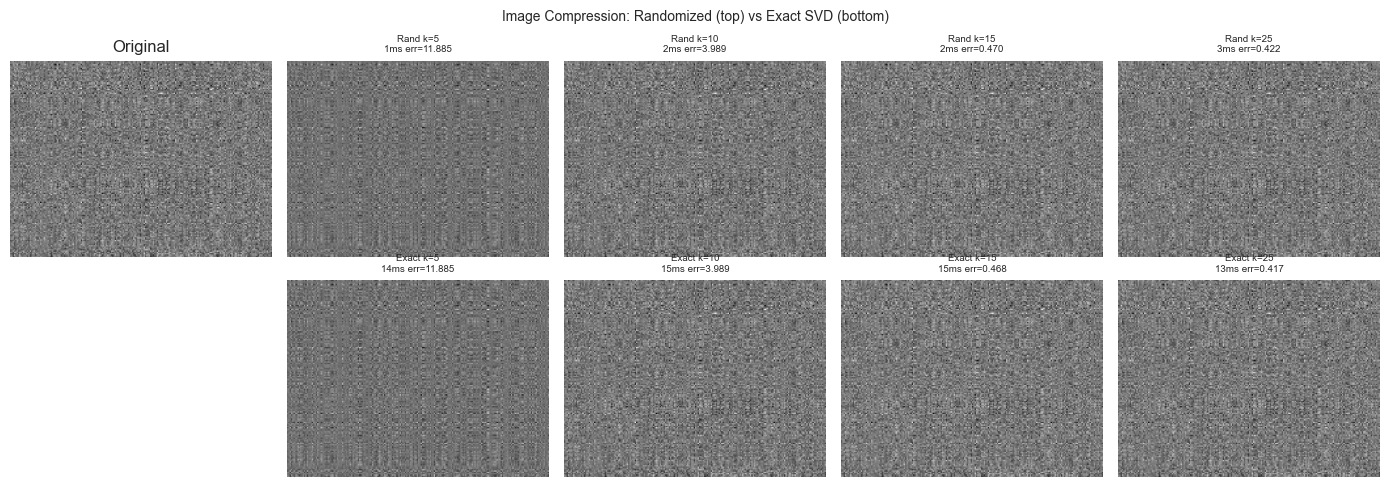

In [4]:
# --- Mini Project: Fast Image Compression via Randomized SVD ---
import time

H, W, K_img = 150, 200, 10
U_img = rng.normal(0,1,(H,K_img)); V_img = rng.normal(0,1,(W,K_img))
img = rng.normal(0,1,(H,W)) * 0.1 + (U_img @ V_img.T)
img = (img - img.min()) / (img.max() - img.min())

K_VALS = [5, 10, 15, 25]
fig, axes = plt.subplots(2, len(K_VALS)+1, figsize=(14, 5))

axes[0,0].imshow(img, cmap='gray'); axes[0,0].set_title('Original'); axes[0,0].axis('off')
axes[1,0].axis('off')

for col, k_c in enumerate(K_VALS):
    # Randomized
    t0 = time.perf_counter()
    Ur, sr, Vtr = randomized_svd(img, k_c)
    t_r = time.perf_counter() - t0
    img_r = np.clip(Ur @ np.diag(sr) @ Vtr, 0, 1)
    err_r = np.linalg.norm(img - img_r, 'fro')

    # Exact
    t0 = time.perf_counter()
    Ue, se, Vte = np.linalg.svd(img, full_matrices=False)
    t_e = time.perf_counter() - t0
    img_e = np.clip(Ue[:,:k_c] @ np.diag(se[:k_c]) @ Vte[:k_c], 0, 1)
    err_e = np.linalg.norm(img - img_e, 'fro')

    axes[0,col+1].imshow(img_r, cmap='gray')
    axes[0,col+1].set_title(f'Rand k={k_c}\n{t_r*1000:.0f}ms err={err_r:.3f}', fontsize=7)
    axes[0,col+1].axis('off')

    axes[1,col+1].imshow(img_e, cmap='gray')
    axes[1,col+1].set_title(f'Exact k={k_c}\n{t_e*1000:.0f}ms err={err_e:.3f}', fontsize=7)
    axes[1,col+1].axis('off')

fig.suptitle('Image Compression: Randomized (top) vs Exact SVD (bottom)', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections

- Randomized algorithms project onto random low-dimensional subspaces, then solve exactly — achieving near-optimal accuracy with provable guarantees and dramatic speedups *(ch173)*.
- JL lemma: $O(\log n/\epsilon^2)$ dimensions suffice to approximately preserve $n$ pairwise distances. Foundational to approximate nearest-neighbor search.
- Randomized SVD replaces $O(mn^2)$ with $O(mnk)$; power iteration improves accuracy for slowly-decaying spectra.
- Sketch-and-solve extends these ideas to least-squares problems.

**Forward:** Randomized methods enable the SVD-based algorithms of ch180–191 at dataset scales encountered in Part IX (millions of samples, high-dimensional features). The JL lemma underpins locality-sensitive hashing used in ch289 (Collaborative Filtering at Scale). Random projections also appear in compressed sensing and sparse recovery.

**Backward:** This chapter extends ch173 (SVD), ch174 (PCA), and ch180 (Image Compression) to the large-scale regime. The error bounds rely on probability theory that will be formalized in Part VIII (ch241–270).